In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

Raw Data → Data Understanding → Data Quality Assessment → Missing Value Handling → Outlier Treatment → Data Type Fixing → Feature Encoding & Scaling → Validation (Before vs After) → Clean Dataset → ML Model

# Method 2 - Rows first then Columns

In [86]:
df = pd.read_csv("train.csv")
df.shape

(1460, 81)

In [87]:
df_null_clm = df.isnull().sum().to_frame("null count")
df_null_clm["null percentage"] = df_null_clm["null count"] / df.shape[0] * 100
df_null_clm

,null count,null percentage
Id,0,0.000000
MSSubClass,0,0.000000
MSZoning,0,0.000000
LotFrontage,259,17.739726
LotArea,0,0.000000
Street,0,0.000000
Alley,1369,93.767123
LotShape,0,0.000000
LandContour,0,0.000000
Utilities,0,0.000000


In [88]:
df_null_per = df_null_clm[df_null_clm["null percentage"] > 20]
df_null_per

,null count,null percentage
Alley,1369,93.767123
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
PoolQC,1453,99.520548
Fence,1179,80.753425
MiscFeature,1406,96.301370


In [89]:
l = df_null_per.index
l

Index(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [90]:
df_drop_clm = df.drop(columns = l)
df_drop_clm.shape

(1460, 75)

contain no null values

In [92]:
df_num = df_drop_clm.select_dtypes(include = ["int64", "float64"])
df_num.shape

(1460, 38)

copy of og dataset

In [94]:
df_num_copy = df_drop_clm.select_dtypes(include = ["int64", "float64"])
df_num_copy.shape

(1460, 38)

In [165]:
l1 = df_num_copy.isnull().sum()[df_num_copy.isnull().sum() > 0].keys()
l1

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='object')

In [95]:
df_num.isnull().sum()

Id                 0
MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

Change in the method here

In [97]:
df_num.isnull().sum()[df_num.isnull().sum() > 0]

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [98]:
df_num.isnull().sum()[df_num.isnull().sum() > 0].keys()

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='object')

In [99]:
df_num['LotFrontage'].replace(np.nan, df_num['LotFrontage'].mean(), inplace = True)

C:\Users\DHANANJAY\AppData\Local\Temp\ipykernel_25972\3801391275.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num['LotFrontage'].replace(np.nan, df_num['LotFrontage'].mean(), inplace = True)


In [100]:
for i in df_num:
    df_num[i].replace(np.nan, df_num[i].mean(), inplace = True)

C:\Users\DHANANJAY\AppData\Local\Temp\ipykernel_25972\3557478940.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num[i].replace(np.nan, df_num[i].mean(), inplace = True)


In [101]:
df_num.isnull().sum()

Id               0
MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

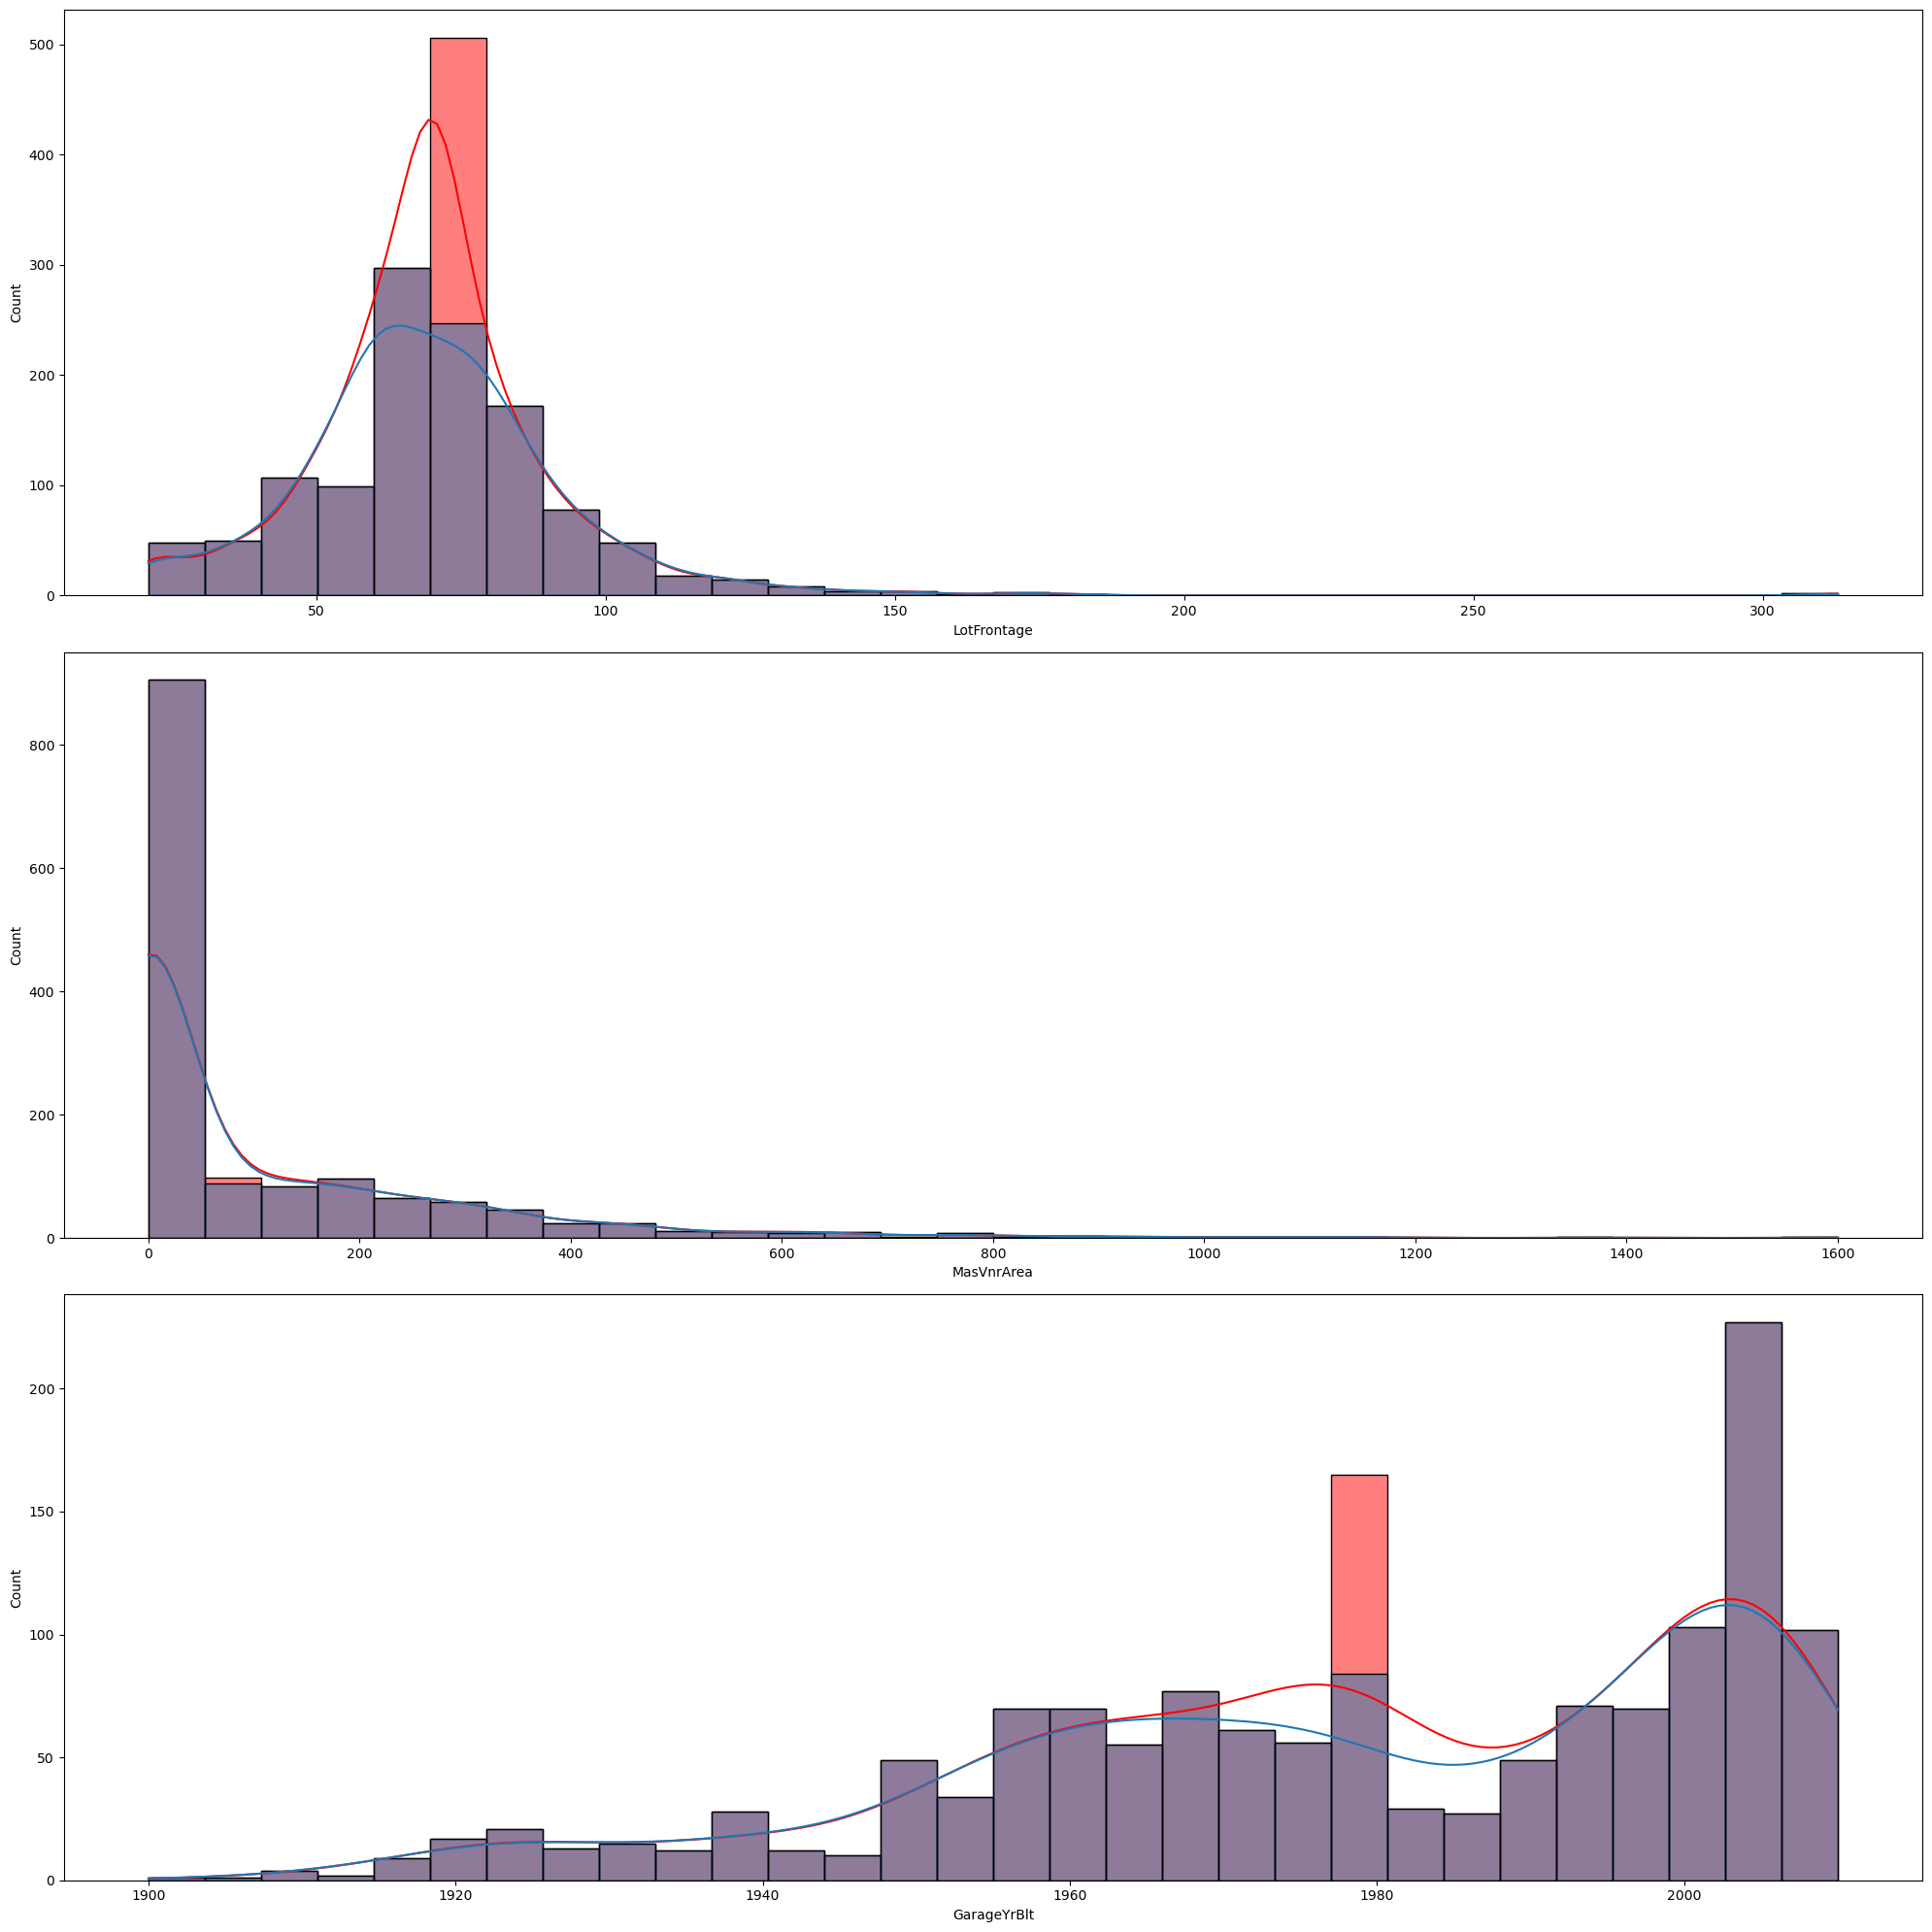

In [169]:
plt.figure(figsize = (20, 20))
for i, var in enumerate(l1):
    plt.subplot(3, 1, i+1)
    sns.histplot(df_num[var], kde = True, bins = 30, color = "Red")
    sns.histplot(df_num_copy[var], kde = True, bins = 30)
plt.tight_layout()
plt.savefig("Histplot visualization of cleaned data for 'train_csv' dataset on numeric columns using Method 2")
plt.show()

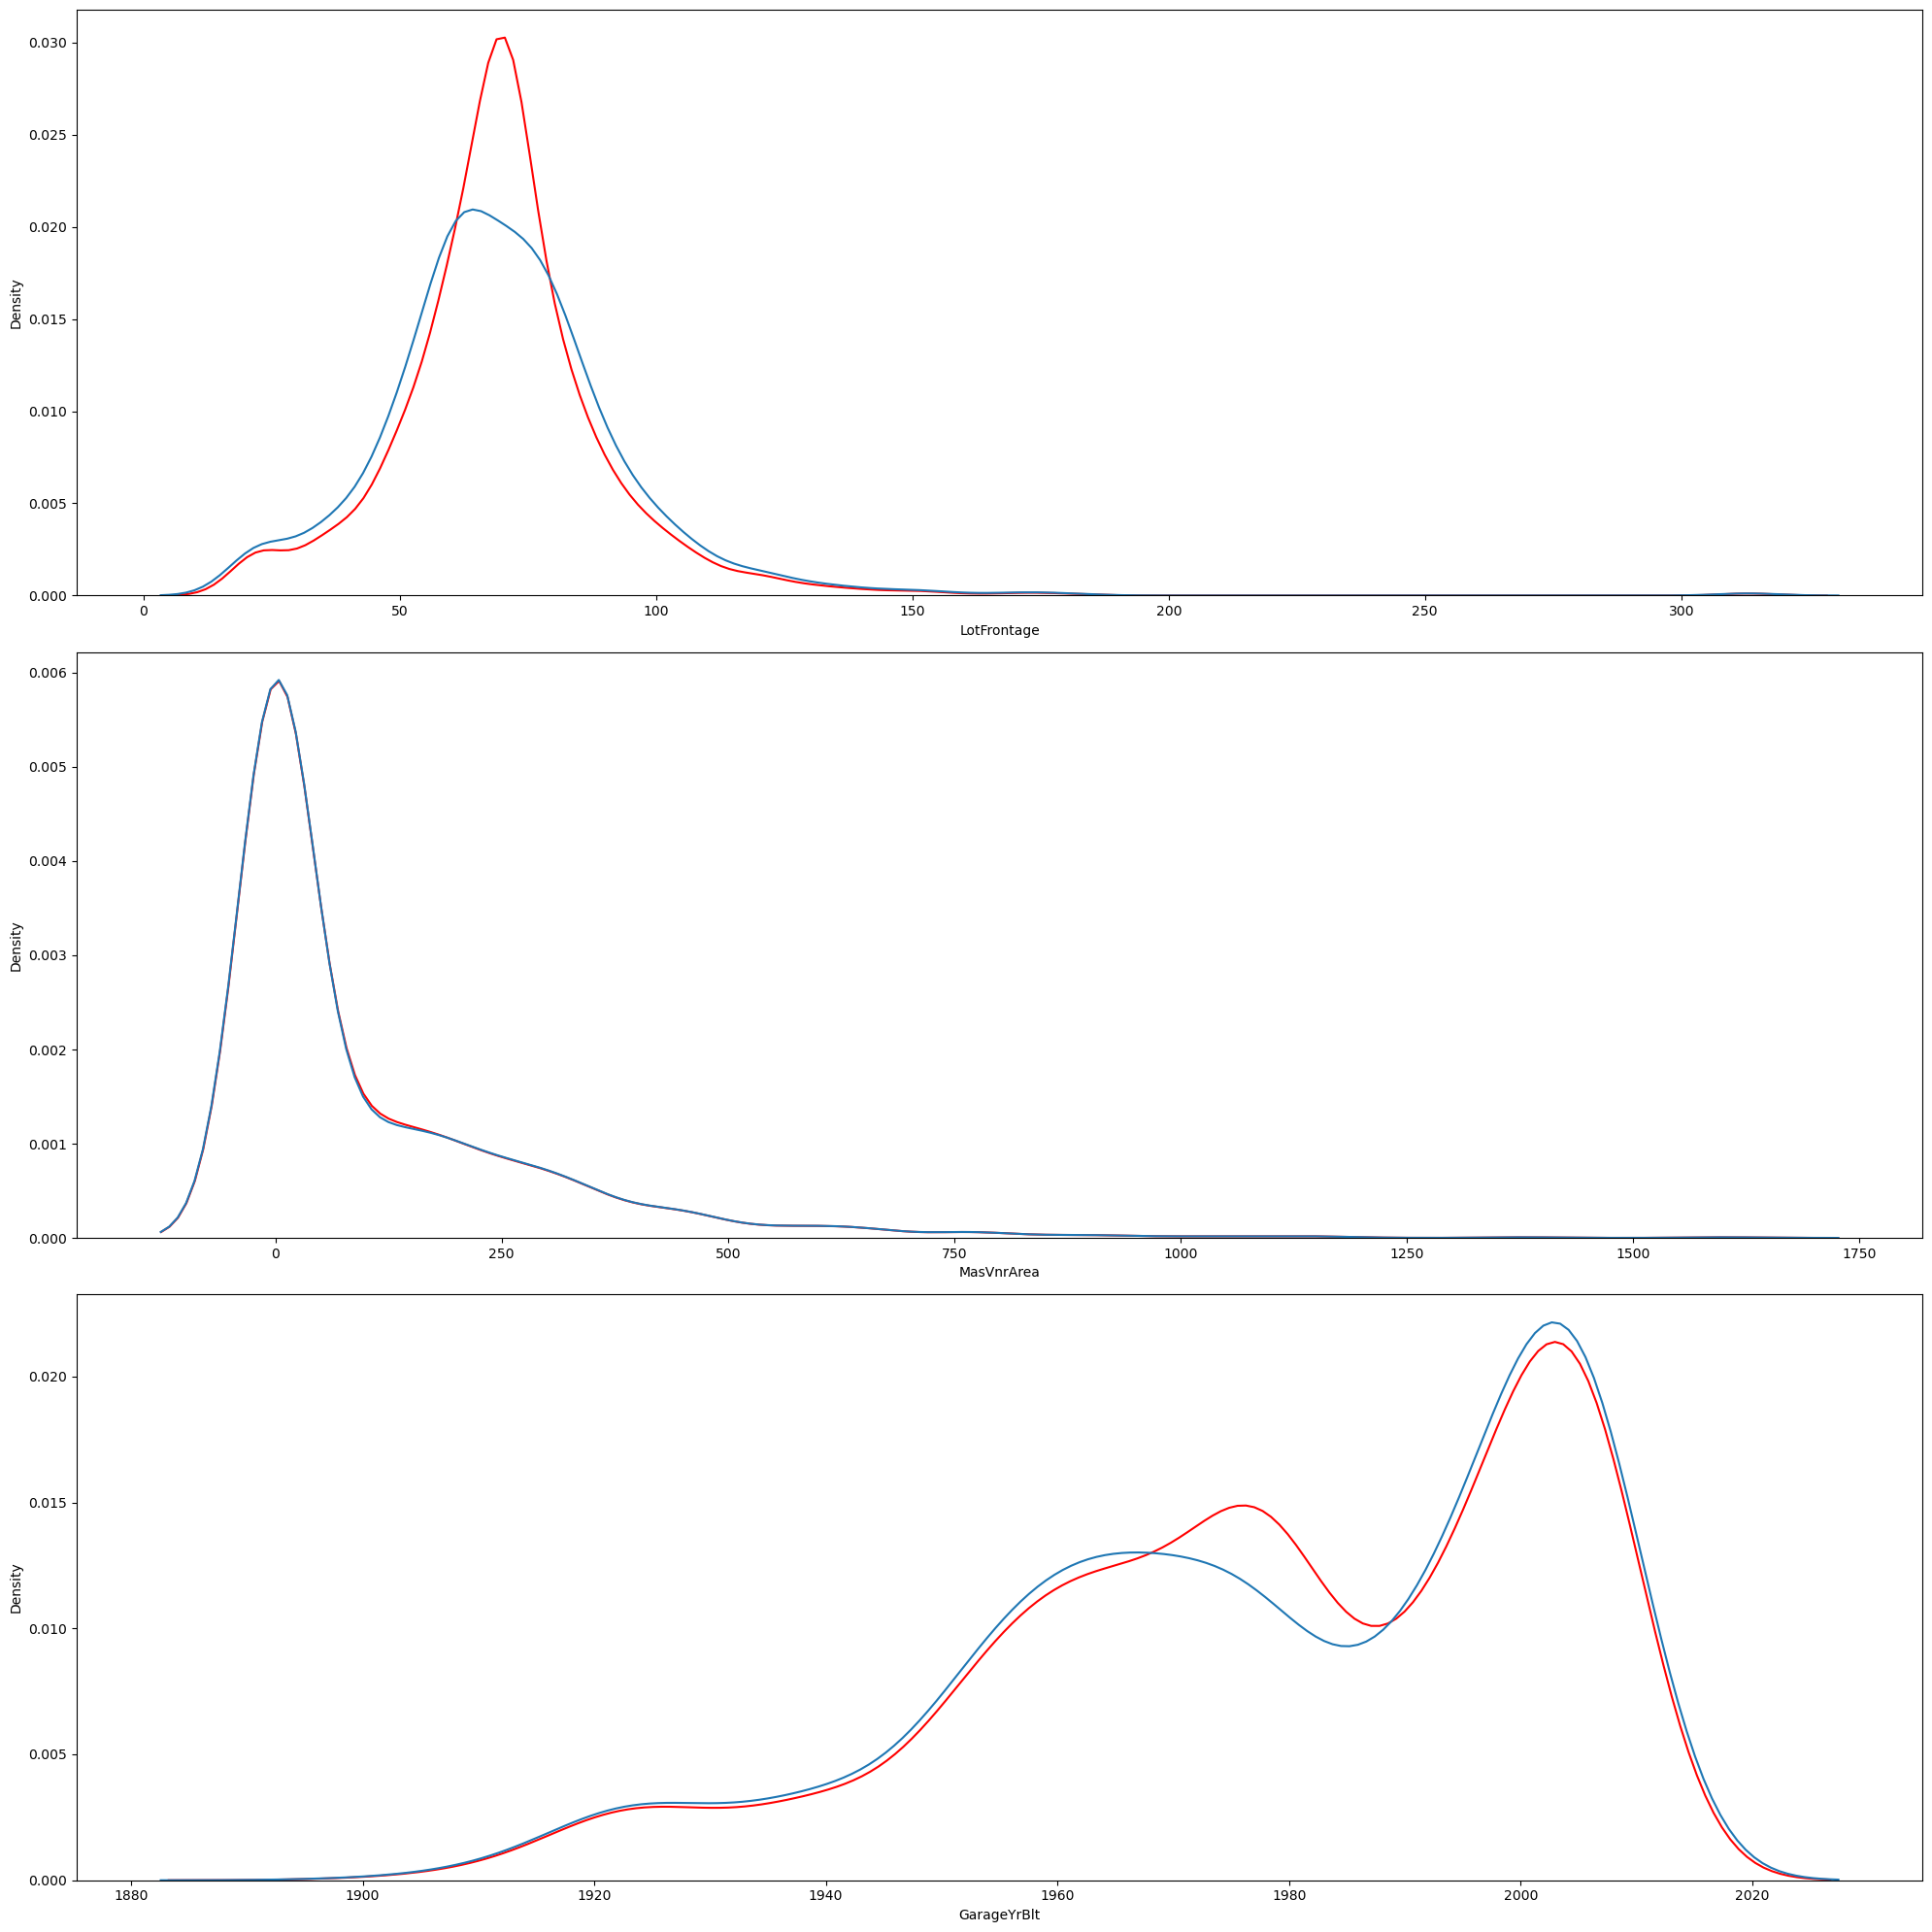

In [167]:
plt.figure(figsize = (20, 20))
for i, var in enumerate(l1):
    plt.subplot(3, 1, i+1)
    sns.kdeplot(df_num[var], color = "Red")
    sns.kdeplot(df_num_copy[var])
plt.tight_layout()
plt.savefig("Kdeplot visualization of cleaned data for 'train_csv' dataset on numeric columns using Method 2")
plt.show()

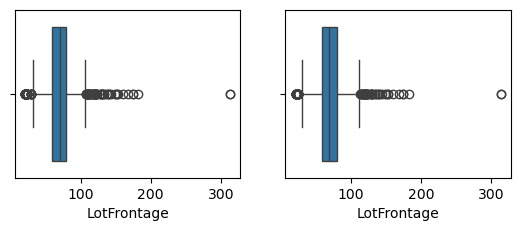

In [181]:
plt.subplot(2, 2, 1)
sns.boxplot(x = df_num["LotFrontage"])

plt.subplot(2, 2, 2)
sns.boxplot(x = df_num_copy["LotFrontage"])
plt.show()